# 1st Example for Estimation of Pi

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random 

The calculated value of Pi = 3.1384


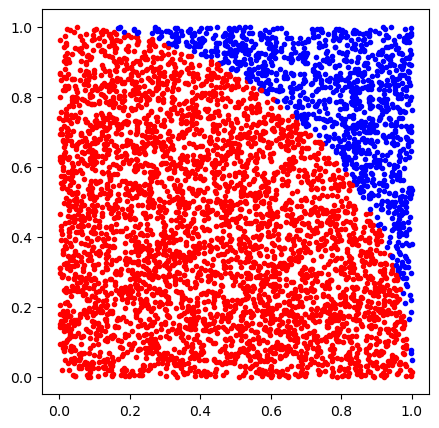

In [2]:
'''Defining Variables'''
total_trials = 5000
circle_hits = 0  #Initialising 

plt.figure(figsize = [5,5])

for i in range(total_trials):
    x = random.uniform(0,1)
    y = random.uniform(0,1)

    distance = (x**2) + (y**2)

    if distance <= 1:
        circle_hits +=1
        plt.scatter(x,y, color='red', marker='.')
    else:
        plt.scatter(x,y, color='blue', marker='.')

pi = 4 * (circle_hits/total_trials)

print("The calculated value of Pi =", pi)

# 2nd Example of Estimating probabilities

Given 5 random cards from a deck of 52, what is the probability of being dealt all hearts ?

In [3]:
import numpy as np
import random

#Defining Variables
total_runs= 1000000
successful_runs = 0

'''Since we only want hearts we will create an array of our deck having 52 elements.'''
'''We will have 13 1s and the rest of the elements of the array will be zero as we only care about hearts.'''

'''deck = [1]*13 + [0]*(52-13) #our deck'''

successful_draw = list(np.ones(5))

for n in range(total_runs):
    #Initialising variables
    cards_tb_drawn = 5
    number_of_cards = 52
    drawn_cards = list([])
    deck = [1]*13 + [0]*(52-13) #Initialised our deck here inside this loop as we want fresh deck for each trial
    random.shuffle(deck)

    while cards_tb_drawn>0:
        dealt_card = deck.pop(random.randint(0,number_of_cards - 1))
        number_of_cards -= 1 
        cards_tb_drawn -=1
        drawn_cards.append(dealt_card)

    is_success = drawn_cards == successful_draw

    if is_success == True:
        successful_runs +=1

success_probability = successful_runs / total_runs
print("The probability for a successful event to occur =",success_probability)

The probability for a successful event to occur = 0.000536


# 3rd Example Stopping-time experiment with dice

In [4]:
import numpy as np
import random

#Initialise Parameters
T = 1000
total_trials = 10000

'''The random variable R represents the number of throws required to reach or exceed T '''

summation_Ri = 0

for i in range(total_trials):
    cumulative_sum = 0
    k = 0
    while cumulative_sum < T:
        dice_sum = (random.randint(1,8) + random.randint(1,8) + random.randint(1,8) ) #Sum from rolling three dices independently
        cumulative_sum += dice_sum
        k += 1

    summation_Ri += k

expected_R = summation_Ri/total_trials
print("Estimated E[R] =", expected_R)

Estimated E[R] = 74.6168


# 1-D Random Walk

In this, we will empirically verify that , E[Xn​]=0 and E[Xn^2​]=n using Monte Carlo Simulation

The expected position after n steps =  -0.04952
The expected variance after n steps =  100.0263999754777


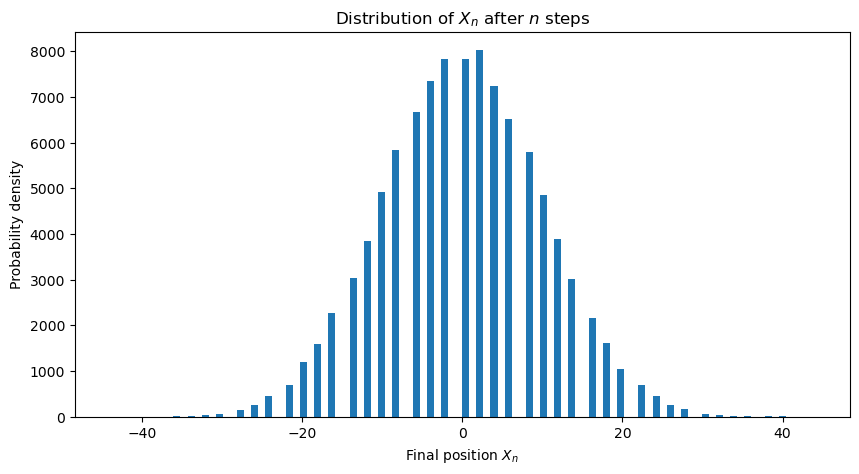

In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt

#Initialise variables
number_of_walk = 100000
n_steps = 100 # Length of each random walk
pos_list = list([])

for j in range(number_of_walk):
    position = 0

    for i in range(n_steps):
        next_step = 2*(random.randint(0,1)) - 1
        position += next_step

    pos_list.append(position)

num_bins = 100

expected_position = sum(pos_list) / number_of_walk

variance = (sum(dummy**2 for dummy in pos_list) - (expected_position ** 2)) / number_of_walk

print("The expected position after n steps = ", expected_position)
print("The expected variance after n steps = ", variance)
# Plotting Part
plt.figure(figsize=[10,5])
plt.hist(pos_list, num_bins)
plt.xlabel("Final position $X_n$")
plt.ylabel("Probability density")
plt.title("Distribution of $X_n$ after $n$ steps")
plt.show()

Here, we chose number of steps in the random walk, n = 100

Our expected position is coming close to 0.

The variance is coming close to 100 which is the number of steps taken here.

# 5th Example on Inverse Sampling

## Physical Context

Consider a radioactive decay process or the mean free path in a scattering experiment.

The waiting time $$T$$ between decay events follows an **exponential distribution**:

$$
f_T(t) = \lambda e^{-\lambda t}, \quad t \ge 0
$$

$$where\ \lambda\ is\ the\ decay\ constant\ (rate)$$

---

## Step 1: Compute the CDF Analytically

The cumulative distribution function (CDF) is obtained by integrating the probability density function:

$$
F_T(t) = \int_{0}^{t} \lambda e^{-\lambda x} \, dx
       = 1 - e^{-\lambda t}
$$

---

## Step 2: Invert the CDF

Let

$$
U \sim \mathrm{Uniform}(0,1)
$$

Set the CDF equal to the uniform random variable:

$$
U = 1 - e^{-\lambda t}
$$

Solving for $$t$$:

$$
t = -\frac{1}{\lambda} \ln(1 - U)
$$

---

This procedure is known as **inverse transform sampling**.


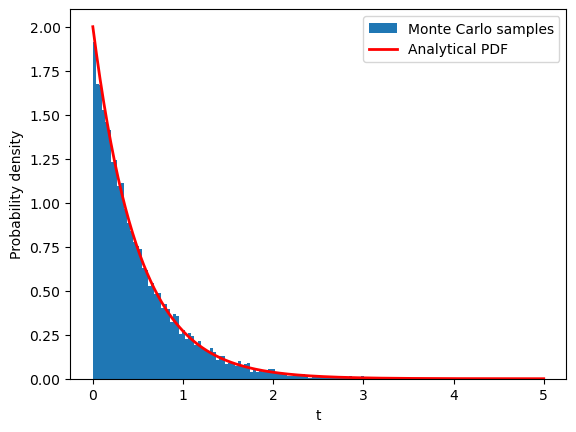

In [6]:
import numpy as np
import matplotlib.pyplot as plt


lambda_value = 2.0      
total_random_var = 10000           


U = np.random.uniform(0, 1, size=total_random_var) #Uniform random variables


T = -np.log(1-U) / lambda_value #Inverse CDF as calculated analytically


t_vals = np.linspace(0, 5, 500)
pdf = lambda_value * np.exp(-lambda_value* t_vals) #Theoretical PDF


plt.hist(T, bins=120,density=True ,label="Monte Carlo samples")
plt.plot(t_vals, pdf, 'r', lw=2, label="Analytical PDF")
plt.xlabel("t")
plt.ylabel("Probability density")
plt.legend()
plt.show()
